In [1]:
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from ocp_formulation import setup_ocp
from utils import unpack_solution, plot_trajectory, show_interactive_simulation, warm_start_from_w
from track_constraints import Pl_vis, Pu_vis, Pl_expr, Pu_expr

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:    12563
Number of nonzeros in inequality constraint Jacobian.:     2000
Number of nonzeros in Lagrangian Hessian.............:     9001

Total number of variables............................:     2001
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        1
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1402
Total number of inequality constraints...............:     1600
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:     1600

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  7.5000000e+00 1.70e+00 1.24e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

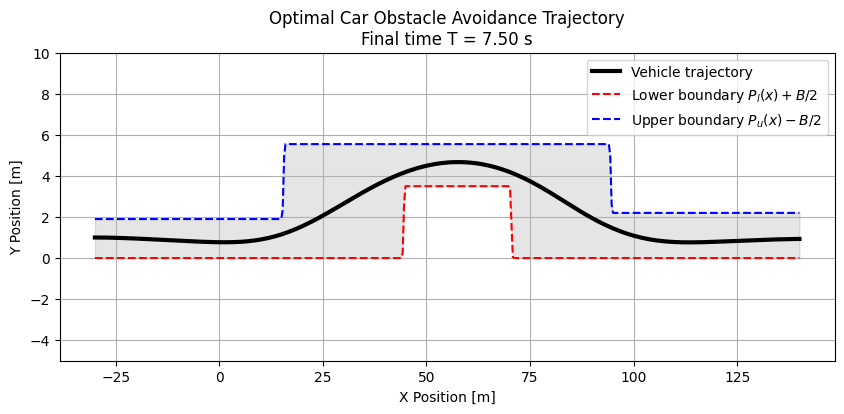

In [28]:
# Problem parameters
gear = 2  # selected gear for entire trajectory
dt = 0.1  # initial guess for time step
N = 200  # number of shooting intervals
B = 1.5

# Setup and solve the OCP
x0 = [-30, 1.0, 10, 0, 0, 0, 0]
solver, nlp, integrator, lbg, ubg = setup_ocp(x0, gear, dt, N)

# Dimensions
nx, nu = 7, 3
w0 = np.zeros(nlp['x'].shape[0])



# State trajectory initial guess
x_sym = ca.MX.sym('x')
Pl_fun = ca.Function('Pl_fun', [x_sym], [Pl_expr(x_sym)])
Pu_fun = ca.Function('Pu_fun', [x_sym], [Pu_expr(x_sym)])

for i in range(N):
    x_guess = -30 + (140 + 30) * i / (N - 1)
    if 0 <= x_guess <= 140:
        pl_val = Pl_fun(x_guess).full().item()
        pu_val = Pu_fun(x_guess).full().item()
        y_guess = 0.5 * (pl_val + pu_val)
        # y_guess = 0
    else:
        y_guess = 0.0

    w0[i * nx: (i + 1) * nx] = [x_guess, y_guess, 10, 0, 0, 0, 0]

# Control trajectory initial guess
for i in range(N):
    ctrl_base = nx * N + i * nu
    if 15 < w0[i * nx] < 30:
        w0[ctrl_base] = 0.025
    elif 30 < w0[i * nx] < 45:
        w0[ctrl_base] = -0.025
    elif 70 < w0[i * nx] < 80:
        w0[ctrl_base] = -0.025
    elif 80 < w0[i * nx] < 95:
        w0[ctrl_base] = 0.025
    else:
        w0[ctrl_base] = 0
    w0[ctrl_base + 1] = 0.0
    w0[ctrl_base + 2] = 0.5

# Initial state guess
w0[0:nx] = x0
# Initial guess for final time T
w0[-1] = 7.5
# Bounds on decision variables
lbw = [-ca.inf] * (nlp['x'].shape[0] - 1) + [0.0]
ubw = [ca.inf] * (nlp['x'].shape[0] - 1) + [20.0]

# Solve NLP
solution = solver(x0=w0, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg)
w_opt = solution['x']

# Unpack and visualize solution
X_opt, U_opt, T_opt = unpack_solution(solution['x'], N, integrator, nx=nx, nu=nu)
print("Solved:", solver.stats()['success'])
print("Final time T_opt:{:.4f}".format(T_opt))
print("Final position X:{:.2f}".format(X_opt[-1, 0]))
print("Final yaw angle Psi:", X_opt[-1, 5])

# Plot the trajectory
plot_trajectory(X_opt, T_opt, track=True, title='Optimal Car Obstacle Avoidance Trajectory')
# 
# # Optional: slider demo (only in notebook)
# try:
#     from IPython import get_ipython
# 
#     if get_ipython():
#         print("\nLaunching interactive simulation widget (Milestone 2 demo)...")
#         show_interactive_simulation(N=N, dt=dt, gear=gear)
# except ImportError:
#     print("Interactive widgets require Jupyter/IPython environment.")

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:    12563
Number of nonzeros in inequality constraint Jacobian.:     2000
Number of nonzeros in Lagrangian Hessian.............:     9001

Total number of variables............................:     2001
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        1
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1402
Total number of inequality constraints...............:     1600
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:     1600

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  7.2660007e+00 6.10e-02 1.78e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

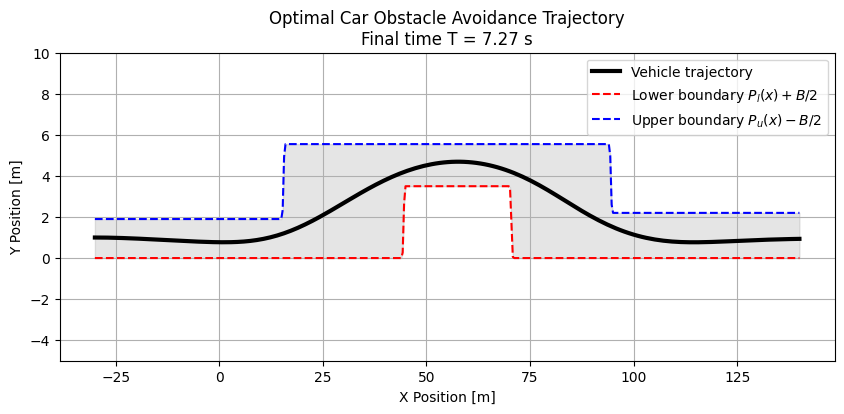

In [20]:
N_new = 200

w0_new = warm_start_from_w(w_opt, N_old=N, N_new=N_new, integrator=integrator, nx=7, nu=3)
solver, nlp, integrator, lbg_new, ubg_new = setup_ocp(x0, gear, dt, N_new)
lbw_new = [-ca.inf] * (nlp['x'].shape[0] - 1) + [0.0]
ubw_new = [ca.inf] * (nlp['x'].shape[0] - 1) + [20.0]
solution = solver(x0=w0_new, lbx=lbw_new, ubx=ubw_new, lbg=lbg_new, ubg=ubg_new)

# Unpack and visualize solution
X_opt_new, U_opt_new, T_opt_new = unpack_solution(solution['x'], N_new, integrator, nx=nx, nu=nu)
print("Solved:", solver.stats()['success'])
print("Final time T_opt:{:.4f}".format(T_opt_new))
print("Final position X:{:.2f}".format(X_opt_new[-1, 0]))
print("Final yaw angle Psi:", X_opt_new[-1, 5])

# Plot the trajectory
plot_trajectory(X_opt_new, T_opt_new, track=True, title='Optimal Car Obstacle Avoidance Trajectory')

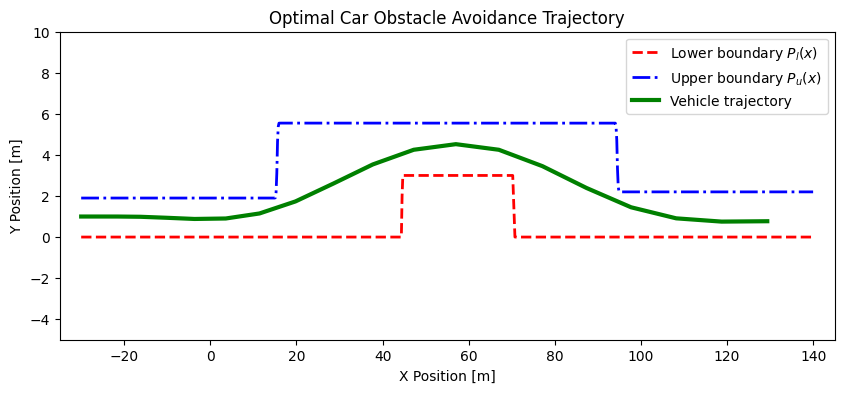

In [4]:
x_car = X_opt[:, 0]
y_car = X_opt[:, 1]
N = len(x_car)

# 生成用于画边界的等间距 X
x_bound = np.linspace(x_car.min(), x_car.max(), 1000)
# 向量化边界函数
Pl_vec = np.vectorize(Pl_vis)
Pu_vec = np.vectorize(Pu_vis)
lower_bound = Pl_vec(x_bound)
upper_bound = Pu_vec(x_bound)

# ———— 绘图和动画设置 ————
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(x_bound.min() - 5, x_bound.max() + 5)
ax.set_ylim(min(lower_bound.min(), y_car.min()) - 1, max(upper_bound.max(), y_car.max()) + 1)
ax.set_xlabel("X Position [m]")
ax.set_ylabel("Y Position [m]")
ax.set_ylim(-5, 10)
ax.set_title("Optimal Car Obstacle Avoidance Trajectory")

# 先画完整边界
low_line, = ax.plot(x_bound, lower_bound, 'r--', lw=2, label='Lower boundary $P_l(x)$')
up_line, = ax.plot(x_bound, upper_bound, 'b-.', lw=2, label='Upper boundary $P_u(x)$')
# 再初始化车辆轨迹线
traj_line, = ax.plot([], [], color='green', lw=3, label='Vehicle trajectory')
ax.legend(loc='upper right')


def init():
    traj_line.set_data([], [])
    return (traj_line,)


def update(i):
    # 只更新车辆轨迹到第 i 个点
    traj_line.set_data(x_car[:i], y_car[:i])
    return (traj_line,)


anim = FuncAnimation(
    fig,
    update,
    frames=x_car.shape[0],
    init_func=init,
    interval=50,
    blit=True
)

anim = FuncAnimation(fig, update, init_func=init,
                     frames=N, interval=50, blit=True, repeat=False)

html_snippet = anim.to_jshtml()
with open("trajectory_anim.html", "w") as f:
    f.write(html_snippet)

# 在 Notebook 查看
HTML(html_snippet)